In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import argparse
from pycbc.io import WaveformArray, HFile
from pycbc import vetoes, psd, waveform, strain, scheme, fft, filter
import matplotlib.pyplot as plt

In [3]:
parser = argparse.ArgumentParser()
parser.add_argument('--approximant', type=str, required=True)

opt = parser.parse_args('--approximant SEOBNRv5E'.split())

In [4]:
row = WaveformArray.from_kwargs(
            mass1=5,
            mass2=5,
            spin1x=0,
            spin1y=0,
            spin1z=0,
            spin2x=0,
            spin2y=0,
            spin2z=0,
            eccentricity=0.3,
            rel_anomaly=0.1)

In [5]:
row.fieldnames

('mass1',
 'mass2',
 'spin1x',
 'spin1y',
 'spin1z',
 'spin2x',
 'spin2y',
 'spin2z',
 'eccentricity',
 'rel_anomaly')

In [11]:
approximant = waveform.bank.parse_approximant_arg(opt.approximant, row)[0]

In [12]:
approximant

'SEOBNRv5E'

In [13]:
row

rec.array([(5, 5, 0, 0, 0, 0, 0, 0, '1', '0.1')],
          dtype=[('mass1', '<i8'), ('mass2', '<i8'), ('spin1x', '<i8'), ('spin1y', '<i8'), ('spin1z', '<i8'), ('spin2x', '<i8'), ('spin2y', '<i8'), ('spin2z', '<i8'), ('eccentricity', '<U1'), ('rel_anomaly', '<U3')])

In [14]:
row[0]

(5, 5, 0, 0, 0, 0, 0, 0, '1', '0.1')

In [19]:
pycbc.waveform.waveform.fd_approximants()

['EccentricFD',
 'TaylorF2',
 'TaylorF2Ecc',
 'TaylorF2NLTides',
 'TaylorF2RedSpin',
 'TaylorF2RedSpinTidal',
 'SpinTaylorF2',
 'EOBNRv2_ROM',
 'EOBNRv2HM_ROM',
 'SEOBNRv1_ROM_EffectiveSpin',
 'SEOBNRv1_ROM_DoubleSpin',
 'SEOBNRv2_ROM_EffectiveSpin',
 'SEOBNRv2_ROM_DoubleSpin',
 'SEOBNRv2_ROM_DoubleSpin_HI',
 'Lackey_Tidal_2013_SEOBNRv2_ROM',
 'SEOBNRv4_ROM',
 'SEOBNRv4HM_ROM',
 'SEOBNRv4_ROM_NRTidal',
 'SEOBNRv4_ROM_NRTidalv2',
 'SEOBNRv4_ROM_NRTidalv2_NSBH',
 'SEOBNRv4T_surrogate',
 'IMRPhenomA',
 'IMRPhenomB',
 'IMRPhenomC',
 'IMRPhenomD',
 'IMRPhenomD_NRTidal',
 'IMRPhenomD_NRTidalv2',
 'IMRPhenomNSBH',
 'IMRPhenomHM',
 'IMRPhenomP',
 'IMRPhenomPv2',
 'IMRPhenomPv2_NRTidal',
 'IMRPhenomPv2_NRTidalv2',
 'SpinTaylorT4Fourier',
 'SpinTaylorT5Fourier',
 'NRSur4d2s',
 'IMRPhenomXAS',
 'IMRPhenomXHM',
 'IMRPhenomPv3',
 'IMRPhenomPv3HM',
 'IMRPhenomXP',
 'IMRPhenomXPHM',
 'SEOBNRv5_ROM',
 'IMRPhenomXAS_NRTidalv2',
 'IMRPhenomXP_NRTidalv2',
 'IMRPhenomXO4a',
 'ExternalPython',
 'SEOBNRv5HM

In [20]:
pycbc.waveform.waveform._scheme.mgr.state

In [22]:
type(pycbc.waveform.waveform._scheme.mgr.state)

pycbc.scheme.DefaultScheme

In [21]:
wav_gen = pycbc.waveform.waveform.fd_wav[type(pycbc.waveform.waveform._scheme.mgr.state)]

In [24]:
wav_gen['SEOBNRv5E']

<function genwave.gen_seobnrv5e_fd(**p)>

In [48]:
hp, hc = wav_gen['SEOBNRv5E'](duration=None, return_hc=False,rel_anomaly=0.1,coa_phase=0.1,f_lower=20,delta_f=1/32,mass1=5,mass2=5,eccentricity=0.3)

In [50]:
hp2, _ = wav_gen['SEOBNRv5E'](duration=None, return_hc=False,rel_anomaly=0.1,coa_phase=0.1,f_lower=20,delta_f=1/32,mass1=5,mass2=5,eccentricit=0.3)

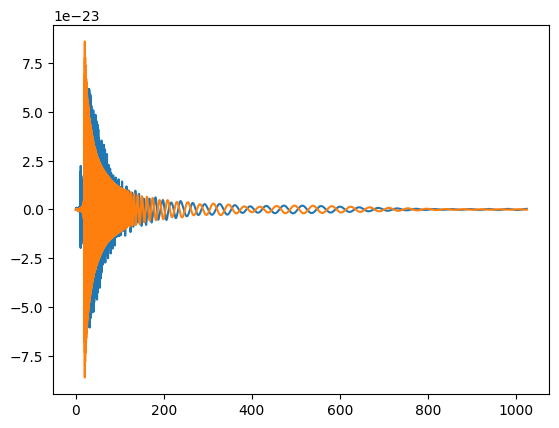

In [51]:
plt.plot(hp.sample_frequencies, hp)
plt.plot(hp2.sample_frequencies, hp2)